# Results Analysis: Cluster Insights

Load clustering results, analyze mean features per cluster, visualize with bar charts, and print insights.

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster distribution:
cluster
2    14
0     7
1     2
Name: count, dtype: int64
Clustering results saved to data/processed/coin_clusters.csv
Mean features per cluster:
         log_return    vol_7d        Volume     Marketcap
cluster                                                  
0          0.005297  0.070521  1.734881e+09  1.179054e+10
1          0.001029  0.019554  1.515761e+10  6.354496e+10
2          0.001655  0.053175  5.917432e+08  3.007896e+09


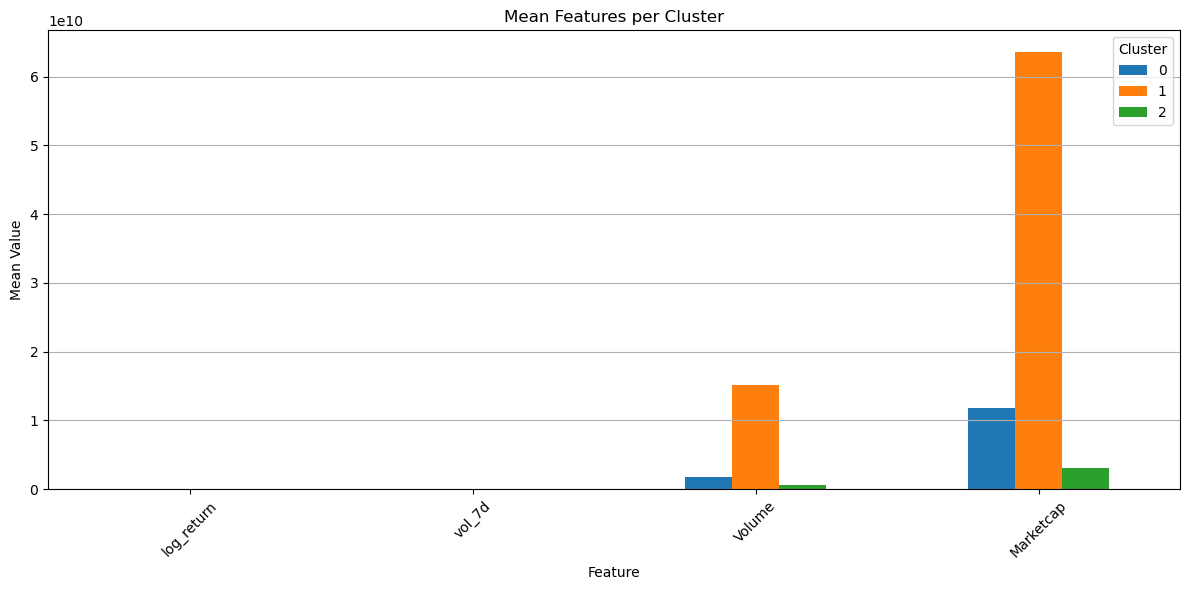


Cluster Insights:

Cluster 0 (7 coins): ['coin_Aave', 'coin_BinanceCoin', 'coin_ChainLink', 'coin_Ethereum', 'coin_Polkadot', 'coin_Solana', 'coin_Uniswap']
  - Avg Log Return: 0.005297
  - Avg Volatility: 0.070521
  - Avg Volume: 1.73e+09
  - Avg Marketcap: 1.18e+10
  Insight: small-cap coins with high volatility.

Cluster 1 (2 coins): ['coin_Bitcoin', 'coin_Tether']
  - Avg Log Return: 0.001029
  - Avg Volatility: 0.019554
  - Avg Volume: 1.52e+10
  - Avg Marketcap: 6.35e+10
  Insight: large-cap coins with low volatility.

Cluster 2 (14 coins): ['coin_Cardano', 'coin_Cosmos', 'coin_CryptocomCoin', 'coin_Dogecoin', 'coin_EOS', 'coin_Iota', 'coin_Litecoin', 'coin_Monero', 'coin_NEM', 'coin_Stellar', 'coin_Tron', 'coin_USDCoin', 'coin_WrappedBitcoin', 'coin_XRP']
  - Avg Log Return: 0.001655
  - Avg Volatility: 0.053175
  - Avg Volume: 5.92e+08
  - Avg Marketcap: 3.01e+09
  Insight: small-cap coins with low volatility.


In [4]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Ensure the notebook runs from the project root
project_root = Path(r"D:/BTLDATA/DATA_MINING_PROJECT")
os.chdir(project_root)

# Load processed features
df = pd.read_parquet("data/processed/crypto_features.parquet")

# Drop any remaining NaNs
df.dropna(inplace=True)

# Aggregate features by coin
agg_features = df.groupby("coin").agg({
    "log_return": "mean",
    "vol_7d": "mean",
    "Volume": "mean",
    "Marketcap": "mean",
}).reset_index()

# Features for clustering
features = ["log_return", "vol_7d", "Volume", "Marketcap"]
X = agg_features[features]

# Scale and cluster
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
agg_features["cluster"] = clusters

# Print cluster distribution
print("Cluster distribution:")
print(agg_features["cluster"].value_counts())

# Save clustering results
agg_features.to_csv("data/processed/coin_clusters.csv", index=False)
print("Clustering results saved to data/processed/coin_clusters.csv")

# Compute mean features per cluster
cluster_means = agg_features.groupby("cluster")[features].mean()
print("Mean features per cluster:")
print(cluster_means)

# Visualize cluster characteristics with bar charts
cluster_means.T.plot(kind="bar", figsize=(12, 6))
plt.title("Mean Features per Cluster")
plt.ylabel("Mean Value")
plt.xlabel("Feature")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Print insights about each cluster
print("\nCluster Insights:")
for cluster in cluster_means.index:
    means = cluster_means.loc[cluster]
    coins_in_cluster = agg_features[agg_features["cluster"] == cluster]["coin"].tolist()
    print(f"\nCluster {cluster} ({len(coins_in_cluster)} coins): {coins_in_cluster}")
    print(f"  - Avg Log Return: {means['log_return']:.6f}")
    print(f"  - Avg Volatility: {means['vol_7d']:.6f}")
    print(f"  - Avg Volume: {means['Volume']:.2e}")
    print(f"  - Avg Marketcap: {means['Marketcap']:.2e}")
    
    # Simple insights
    if means['vol_7d'] > cluster_means['vol_7d'].median():
        vol_desc = "high volatility"
    else:
        vol_desc = "low volatility"
    
    if means['Marketcap'] > cluster_means['Marketcap'].median():
        cap_desc = "large-cap"
    else:
        cap_desc = "small-cap"
    
    print(f"  Insight: {cap_desc} coins with {vol_desc}.")

## Summary Table: Mean Features per Cluster

Display a formatted table showing the mean return, volatility, and market cap for each cluster.

In [5]:
# Display the summary table
display(cluster_means.style.format({
    'log_return': '{:.6f}',
    'vol_7d': '{:.6f}',
    'Volume': '{:.2e}',
    'Marketcap': '{:.2e}'
}).set_caption("Mean Features per Cluster"))

,log_return,vol_7d,Volume,Marketcap
cluster,,,,
0,0.005297,0.070521,1.73e+09,1.18e+10
1,0.001029,0.019554,1.52e+10,6.35e+10
2,0.001655,0.053175,5.92e+08,3.01e+09
